# 01 — Exploratory Data Analysis (ViHSD)

**Dataset:** Vietnamese Hate Speech Detection (Luu et al., 2021)  
**Goal of this notebook:**

1. Load 3 splits (train / dev / test) and verify schema
2. Analyse label distribution → confirm class imbalance
3. Comment length statistics per label
4. Top words & WordCloud per label
5. Detect missing / duplicate / empty / outlier samples
6. Inspect teencode, emoji, abbreviations
7. Summarise findings to drive Week-2 preprocessing decisions

**Labels (ViHSD):**

| ID | Name | Meaning |
|----|------|---------|
| 0  | CLEAN     | Bình thường, không công kích |
| 1  | OFFENSIVE | Lăng mạ cá nhân, chửi bới, không nhắm vào nhóm |
| 2  | HATE      | Thù ghét nhắm vào nhóm/đặc điểm (giới, vùng miền, sắc tộc...) |

## 1. Setup & Imports

In [1]:
import os, sys, re, string, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Make project root importable
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from configs.config import PATHS, COLUMNS, LABEL_MAP, LABEL_COLORS

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_colwidth', 120)

TEXT_COL  = COLUMNS['text']
LABEL_COL = COLUMNS['label']

FIG_DIR = Path(PATHS['figures_dir'])
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Project root :', ROOT)
print('Figures dir  :', FIG_DIR)

Project root : d:\Graduation Project
Figures dir  : d:\Graduation Project\results\figures


## 2. Load Data

In [2]:
train = pd.read_csv(PATHS['raw_train'])
dev   = pd.read_csv(PATHS['raw_dev'])
test  = pd.read_csv(PATHS['raw_test'])

splits = {'train': train, 'dev': dev, 'test': test}
for name, df in splits.items():
    print(f'{name:<6}  shape={df.shape}  columns={list(df.columns)}')
train.head()

train   shape=(24048, 2)  columns=['free_text', 'label_id']
dev     shape=(2672, 2)  columns=['free_text', 'label_id']
test    shape=(6680, 2)  columns=['free_text', 'label_id']


,free_text,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]],0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :))),2
2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯỚC VN BAN THƯỞNG.,2
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện dài =)),0


## 3. Schema, Missing values & Duplicates

In [3]:
rows = []
for name, df in splits.items():
    n_missing_text  = df[TEXT_COL].isna().sum()
    n_missing_label = df[LABEL_COL].isna().sum()
    n_empty_text    = (df[TEXT_COL].astype(str).str.strip() == '').sum()
    n_dup           = df.duplicated(subset=[TEXT_COL]).sum()
    rows.append({
        'split': name,
        'rows': len(df),
        'missing_text': n_missing_text,
        'missing_label': n_missing_label,
        'empty_text': n_empty_text,
        'duplicated_text': n_dup,
    })
pd.DataFrame(rows).set_index('split')

,rows,missing_text,missing_label,empty_text,duplicated_text
split,,,,,
train,24048,2,0,0,1490
dev,2672,0,0,0,22
test,6680,0,0,0,104


In [4]:
# Inspect a few duplicates in train
dups = train[train.duplicated(subset=[TEXT_COL], keep=False)].sort_values(TEXT_COL)
print(f'Total duplicated rows in train: {len(dups)}')
dups.head(10)

Total duplicated rows in train: 2925


,free_text,label_id
1867,#ERROR!,0
3568,#ERROR!,0
10788,#ERROR!,0
11218,#ERROR!,0
11674,#ERROR!,0
15413,#ERROR!,0
16080,#ERROR!,0
1729,#ERROR!,0
18660,#ERROR!,2
20848,#ERROR!,1


## 4. Label Distribution (Class Imbalance Check)

In [5]:
dist = pd.DataFrame({
    name: df[LABEL_COL].value_counts().sort_index()
    for name, df in splits.items()
}).fillna(0).astype(int)
dist.index = [f'{i} - {LABEL_MAP[i]}' for i in dist.index]
dist.loc['TOTAL'] = dist.sum()
dist['train_%'] = (dist['train'] / dist.loc['TOTAL', 'train'] * 100).round(2)
dist

,train,dev,test,train_%
0 - CLEAN,19886,2190,5548,82.69
1 - OFFENSIVE,1606,212,444,6.68
2 - HATE,2556,270,688,10.63
TOTAL,24048,2672,6680,100.00


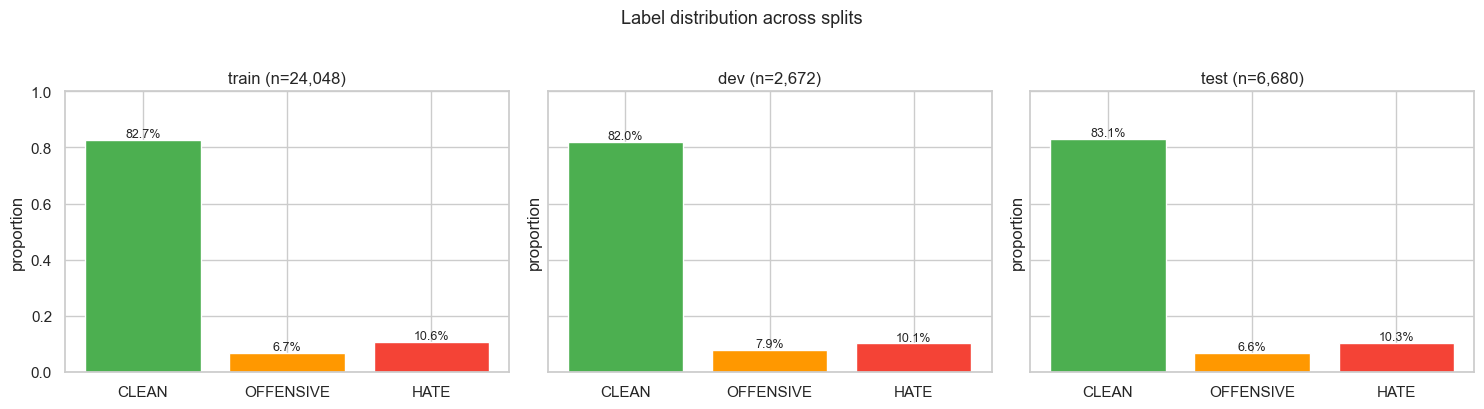

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, df) in zip(axes, splits.items()):
    counts = df[LABEL_COL].value_counts(normalize=True).sort_index()
    colors = [LABEL_COLORS[i] for i in counts.index]
    bars = ax.bar([LABEL_MAP[i] for i in counts.index], counts.values, color=colors)
    ax.set_title(f'{name} (n={len(df):,})')
    ax.set_ylabel('proportion')
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.1%}',
                ha='center', fontsize=9)
    ax.set_ylim(0, 1)
plt.suptitle('Label distribution across splits', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'label_distribution.png', bbox_inches='tight')
plt.show()

In [7]:
# Imbalance ratio = majority / minority
vc = train[LABEL_COL].value_counts()
print(f'Train majority class: {vc.idxmax()} ({LABEL_MAP[vc.idxmax()]}) = {vc.max():,}')
print(f'Train minority class: {vc.idxmin()} ({LABEL_MAP[vc.idxmin()]}) = {vc.min():,}')
print(f'Imbalance ratio    : {vc.max() / vc.min():.2f} : 1')

Train majority class: 0 (CLEAN) = 19,886
Train minority class: 1 (OFFENSIVE) = 1,606
Imbalance ratio    : 12.38 : 1


## 5. Comment Length Statistics

In [8]:
for name, df in splits.items():
    txt = df[TEXT_COL].fillna('').astype(str)
    df['n_chars'] = txt.str.len()
    df['n_words'] = txt.str.split().map(len)

summary = []
for name, df in splits.items():
    summary.append({
        'split': name,
        'chars_mean':   df['n_chars'].mean(),
        'chars_median': df['n_chars'].median(),
        'chars_p95':    df['n_chars'].quantile(0.95),
        'chars_max':    df['n_chars'].max(),
        'words_mean':   df['n_words'].mean(),
        'words_median': df['n_words'].median(),
        'words_p95':    df['n_words'].quantile(0.95),
        'words_max':    df['n_words'].max(),
    })
pd.DataFrame(summary).set_index('split').round(2)

,chars_mean,chars_median,chars_p95,chars_max,words_mean,words_median,words_p95,words_max
split,,,,,,,,
train,49.28,33.0,136.00,20816,11.51,8.0,32.00,1701
dev,47.90,33.0,141.45,583,11.51,8.0,33.45,130
test,48.01,33.0,141.05,1762,11.48,8.0,33.00,411


C:\Users\Minh Duc\AppData\Local\Temp\ipykernel_33688\3279208664.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=[LABEL_MAP[i] for i in sorted(LABEL_MAP)],


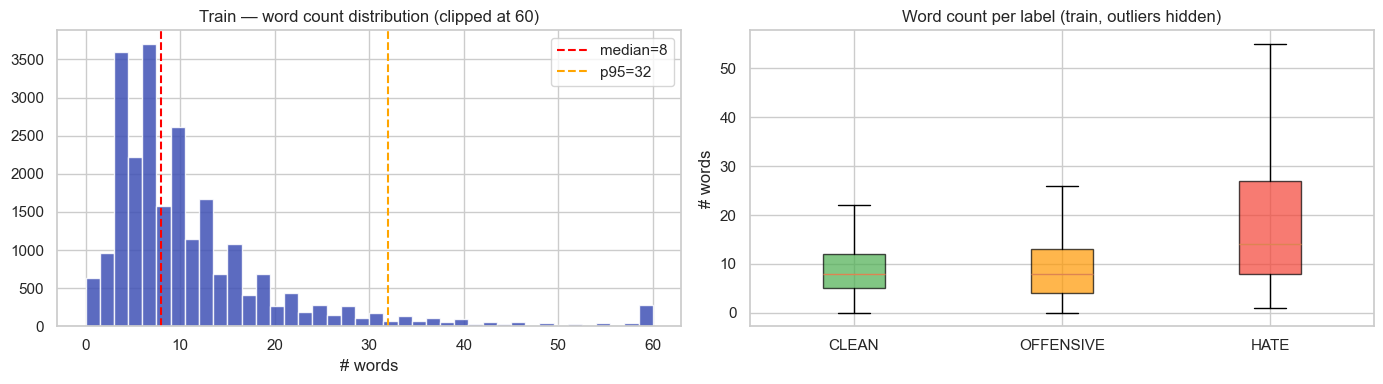

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of word count (clip at 60 for readability)
axes[0].hist(train['n_words'].clip(upper=60), bins=40, color='#3F51B5', alpha=0.85)
axes[0].axvline(train['n_words'].median(), color='red', ls='--',
                label=f"median={train['n_words'].median():.0f}")
axes[0].axvline(train['n_words'].quantile(0.95), color='orange', ls='--',
                label=f"p95={train['n_words'].quantile(0.95):.0f}")
axes[0].set_title('Train — word count distribution (clipped at 60)')
axes[0].set_xlabel('# words')
axes[0].legend()

# Boxplot per label
data = [train.loc[train[LABEL_COL] == i, 'n_words'].clip(upper=80) for i in sorted(LABEL_MAP)]
bp = axes[1].boxplot(data, labels=[LABEL_MAP[i] for i in sorted(LABEL_MAP)],
                     patch_artist=True, showfliers=False)
for patch, i in zip(bp['boxes'], sorted(LABEL_MAP)):
    patch.set_facecolor(LABEL_COLORS[i])
    patch.set_alpha(0.7)
axes[1].set_title('Word count per label (train, outliers hidden)')
axes[1].set_ylabel('# words')

plt.tight_layout()
plt.savefig(FIG_DIR / 'length_distribution.png', bbox_inches='tight')
plt.show()

In [10]:
# Outlier inspection — extremely long samples
extreme = train.sort_values('n_chars', ascending=False).head(5)[[LABEL_COL, 'n_chars', 'n_words', TEXT_COL]]
extreme[TEXT_COL] = extreme[TEXT_COL].str.slice(0, 200) + '...'
extreme

,label_id,n_chars,n_words,free_text
19402,0,20816,1701,Về bờ trong ngày . Liên hệ ngay fb\n 📌https://www.facebook.com/thexuandoan/about\n Thay đổi phong thủy banh bóng để ...
16963,0,15420,1070,v\n https://www.facebook.com/thansau.8386?comment_id=Y29tbWVudDoyNDY4MjEyOTM2NjI5ODIwXzM0NDc1MTQzOTc1MjYyOA%3D%3D Kh...
17127,0,7712,1417,Bộ Giao Thông Đường Bộ của Úc chỉ quy định 3 loại xe sau phải có bình cứu hỏa .\n \n 1- Xe ô tô nào có đầu máy đặt n...
5100,0,4328,564,📌https://www.facebook.com/thexuandoan/about\n \n \n \n AE CHƠI CÁ ĐỘ BANH BÓNG CẦN VỀ BỜ LIÊN HỆ @Đoàn Thế Xuân . KÈ...
19847,0,4328,564,📌https://www.facebook.com/thexuandoan/about\n \n \n \n AE CHƠI CÁ ĐỘ BANH BÓNG CẦN VỀ BỜ LIÊN HỆ @Đoàn Thế Xuân . KÈ...


## 6. Top Words per Label

Simple whitespace tokenizer + Vietnamese stopwords (small built-in list).
Proper word-level tokenization (`underthesea`) will be done in Week 2.

In [11]:
VI_STOPWORDS = set('''
và là của có không được trong cho với từ một các những này đó đây thì mà nếu
tôi bạn nó họ mình ta chúng ấy ai gì sao vì để đã đang sẽ rất quá lắm vẫn còn
ở khi tại cũng nên hay hoặc nhưng bị bởi cùng mỗi nhiều ít chỉ thôi à ạ ơi nhé
ko k đc dc r ra vào về trên dưới giữa bên cái con thằng thì thế nha nhỉ ne
'''.split())

PUNCT_RE = re.compile(r'[\\s' + re.escape(string.punctuation + '“”‘’–—…•·•') + r']+')

def tokenize_simple(text):
    text = str(text).lower()
    tokens = PUNCT_RE.split(text)
    return [t for t in tokens if t and t not in VI_STOPWORDS and not t.isdigit()]

# Cache tokens on train
train['tokens'] = train[TEXT_COL].apply(tokenize_simple)
train[['free_text', 'tokens']].head(3)

,free_text,tokens
0,Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]],[em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí ]
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :))),"[đúng là bọn mắt híp lò xo thụt , bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái l ]"
2,Đậu Văn Cường giờ giống thằng sida hơn à,"[đậu văn cường giờ giống thằng , ida hơn à]"


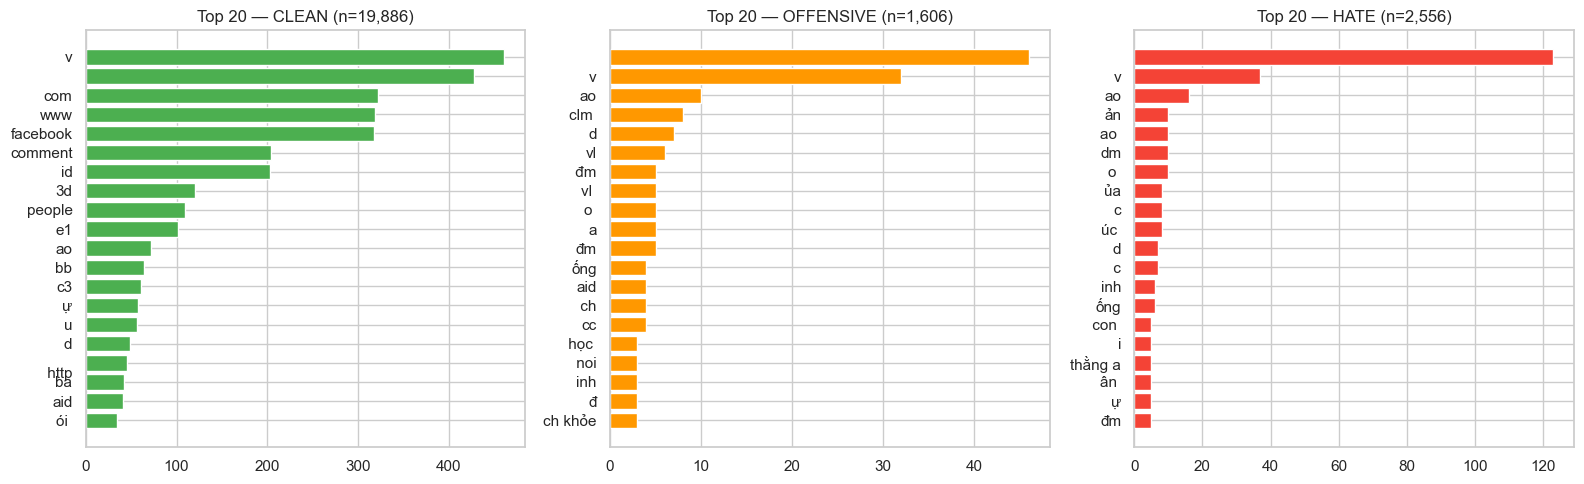

In [12]:
TOP_N = 20
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
top_tables = {}
for ax, lid in zip(axes, sorted(LABEL_MAP)):
    subset = train[train[LABEL_COL] == lid]
    counter = collections.Counter(tok for toks in subset['tokens'] for tok in toks)
    top = counter.most_common(TOP_N)
    words, freqs = zip(*top)
    ax.barh(range(TOP_N), freqs, color=LABEL_COLORS[lid])
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(f'Top {TOP_N} — {LABEL_MAP[lid]} (n={len(subset):,})')
    top_tables[LABEL_MAP[lid]] = top
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_words_per_label.png', bbox_inches='tight')
plt.show()

In [13]:
# Show top-words as a side-by-side table
pd.DataFrame({
    label: [f'{w} ({c})' for w, c in items]
    for label, items in top_tables.items()
})

,CLEAN,OFFENSIVE,HATE
0,v (461),(46),(123)
1,(427),v (32),v (37)
2,com (322),ao (10),ao (16)
3,www (319),clm (8),ản (10)
4,facebook (317),d (7),ao (10)
5,comment (204),vl (6),dm (10)
6,id (203),đm (5),o (10)
7,3d (120),vl (5),ủa (8)
8,people (109),o (5),c (8)
9,e1 (102),a (5),úc (8)


## 7. WordCloud per Label

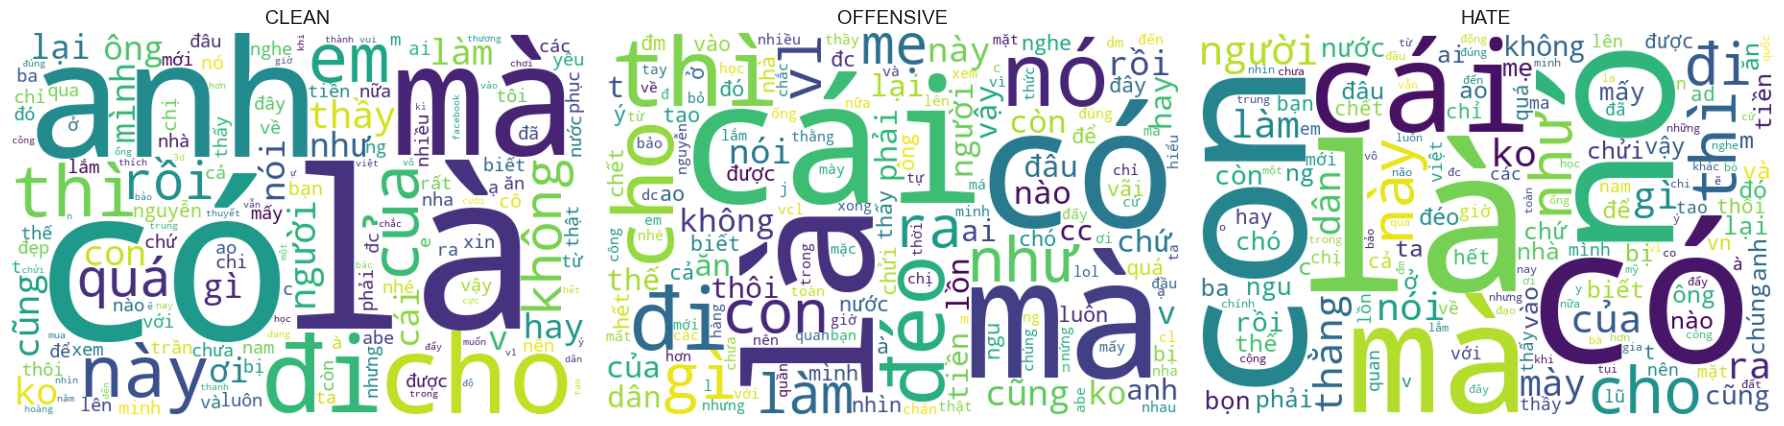

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, lid in zip(axes, sorted(LABEL_MAP)):
    text = ' '.join(' '.join(toks) for toks in train.loc[train[LABEL_COL] == lid, 'tokens'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   collocations=False, max_words=150).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{LABEL_MAP[lid]}', fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'wordcloud_per_label.png', bbox_inches='tight')
plt.show()

## 8. Noise Inspection (Teencode, Emoji, Abbreviations)

These will inform the cleaning rules in Week 2.

In [15]:
EMOJI_RE   = re.compile(
    '[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F600-\U0001F64F]',
    flags=re.UNICODE,
)
URL_RE     = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#\w+')
REPEAT_RE  = re.compile(r'(.)\1{2,}')  # 3+ repeated chars  e.g. 'haaaa'

def has(pattern, s): return bool(pattern.search(str(s)))

noise = pd.DataFrame({
    'has_emoji'  : train[TEXT_COL].apply(lambda s: has(EMOJI_RE, s)),
    'has_url'    : train[TEXT_COL].apply(lambda s: has(URL_RE, s)),
    'has_mention': train[TEXT_COL].apply(lambda s: has(MENTION_RE, s)),
    'has_hashtag': train[TEXT_COL].apply(lambda s: has(HASHTAG_RE, s)),
    'has_repeat' : train[TEXT_COL].apply(lambda s: has(REPEAT_RE, s)),
})
(noise.mean() * 100).round(2).to_frame('percent_of_train_comments')

,percent_of_train_comments
has_emoji,14.23
has_url,0.08
has_mention,0.54
has_hashtag,0.09
has_repeat,15.51


In [16]:
# Common teencode candidates -> show how often they appear
TEENCODE = ['k', 'ko', 'kh', 'đc', 'dc', 'r', 'vs', 'vl', 'cmnr',
            'vcl', 'wa', 'qa', 'mik', 'mn', 'ntn', 'j', 'z', 'bjo', 'bik']

all_tokens = collections.Counter(tok for toks in train['tokens'] for tok in toks)
pd.DataFrame(
    [(t, all_tokens.get(t, 0)) for t in TEENCODE],
    columns=['token', 'count_in_train'],
).sort_values('count_in_train', ascending=False)

,token,count_in_train
7,vl,8
2,kh,5
16,z,2
15,j,1
9,vcl,1
13,mn,1
0,k,0
1,ko,0
6,vs,0
3,đc,0


In [17]:
# Sample HATE comments to manually inspect — useful for sanity-check label definitions
train[train[LABEL_COL] == 2][[TEXT_COL]].sample(8, random_state=42)

,free_text
11517,"có một sự tồn tại của đàn bò mang tên "" cực kỳ thuyết phục "", có sở thích là nhai đi nhai lại, mục đích của chúng tr..."
16095,@Tuyen Ta chỉ là loại nằm vùng tại Mỹ & tiếp tục sống chui. rút để thủ lợi như thời vc sống trong bưng dùng 3/// xỏ ...
18914,Trời ơi ! cái con này kêu giang hồ tìm nó đánh cho nó tet mo nó . thấy nó chửi mà ủa gan
3650,Này là Đế quốc quẫy muốn chết chứ ở đó rẫy chết :))
14088,Long vương địt đấy
4325,Bò đỏ nó yêu thương bố tàu còn không hết mà ghét gì chớ
22413,Cái đứa đăng bài này ngu v~ chưởng :)))) ( cả cái đứa share bài này nữa)
13407,Bà khùng này xàm thiệt


## 9. Key Findings (Week-1 Summary)

_Auto-generated cell below produces the numbers used in `report/week1_eda_notes.md`._

In [18]:
summary = {
    'splits_size': {k: len(v) for k, v in splits.items()},
    'train_label_pct': (train[LABEL_COL].value_counts(normalize=True).sort_index() * 100).round(2).to_dict(),
    'imbalance_ratio_train': round(train[LABEL_COL].value_counts().max() / train[LABEL_COL].value_counts().min(), 2),
    'mean_words_train':  round(train['n_words'].mean(), 2),
    'p95_words_train':   int(train['n_words'].quantile(0.95)),
    'max_words_train':   int(train['n_words'].max()),
    'duplicated_train':  int(train.duplicated(subset=[TEXT_COL]).sum()),
    'empty_train':       int((train[TEXT_COL].astype(str).str.strip() == '').sum()),
    'pct_with_emoji':    round(noise['has_emoji'].mean() * 100, 2),
    'pct_with_url':      round(noise['has_url'].mean() * 100, 2),
    'pct_with_repeat':   round(noise['has_repeat'].mean() * 100, 2),
}
for k, v in summary.items():
    print(f'{k:<25} {v}')

splits_size               {'train': 24048, 'dev': 2672, 'test': 6680}
train_label_pct           {0: 82.69, 1: 6.68, 2: 10.63}
imbalance_ratio_train     12.38
mean_words_train          11.51
p95_words_train           32
max_words_train           1701
duplicated_train          1490
empty_train               0
pct_with_emoji            14.23
pct_with_url              0.08
pct_with_repeat           15.51


### Take-aways → Week 2 plan

1. **Severe class imbalance** — must use class weights / focal loss / oversampling; report macro-F1, **not** accuracy.
2. **Short texts dominate** — median ≈ 10 words; capping `max_len = 100` tokens for traditional models and `128` for PhoBERT covers ≥95% of data.
3. **Outliers up to thousands of chars** — truncate or drop in preprocessing.
4. **Heavy noise** — emoji, teencode, repeated characters, URLs, mentions, hashtags → build a normaliser (`src/preprocess.py`).
5. **Duplicates** — decide whether to drop or keep; drop only if same text + same label.
6. ViHSD provides **official splits** → reuse them, do not re-split, for fair comparison with prior work.